In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
import geopandas as gpd
from netCDF4 import Dataset
import os
# import cv2
import datetime
import numba
import pickle
from shapely.geometry import Point, Polygon
import inspect
import glob
import h5py

import track

# Extract META Data

In [2]:
lonmin = 140 - 2.5
lonmax = 180 + 2.5
latmin = 28  - 2.5
latmax = 40  + 2.5

track.lonmin = lonmin
track.lonmax = lonmax
track.latmin = latmin
track.latmax = latmax

In [3]:
# path = '/Users/jjijack/Documents/Visual Studio Code/Python/EddyNet/META-Data-Converter/'
path = '../META3.1/'

ACS, ACL, CS, CL = track.load_meta_data(path)

In [4]:
track.process_and_save(ACS, 'acs.pkl')
track.process_and_save(ACL, 'acl.pkl')
track.process_and_save(CS, 'cs.pkl')
track.process_and_save(CL, 'cl.pkl')

ACS count: 6738
ACL count: 13597
CS count: 7096
CL count: 15072


# Extract Mat Data

In [2]:
Year = str(2013)

Float_path = './Argo_addFloat'
paths = []

Float_path = './Argo_addFloat'
paths = [os.path.join(Float_path, f'Argo{Year}_{month}.mat') for month in range(1, 13)]

print(paths)

['./Argo_addFloat/Argo2013_1.mat', './Argo_addFloat/Argo2013_2.mat', './Argo_addFloat/Argo2013_3.mat', './Argo_addFloat/Argo2013_4.mat', './Argo_addFloat/Argo2013_5.mat', './Argo_addFloat/Argo2013_6.mat', './Argo_addFloat/Argo2013_7.mat', './Argo_addFloat/Argo2013_8.mat', './Argo_addFloat/Argo2013_9.mat', './Argo_addFloat/Argo2013_10.mat', './Argo_addFloat/Argo2013_11.mat', './Argo_addFloat/Argo2013_12.mat']


In [ ]:
# 定义列名
columns = [
    "Year", "Month", "Day", "Longitude", "Latitude", "Depth_m", "DO_mol_kg", "Salinity_psu",
    "Temperature_degC", "Oxygen_flag", "Oxygen_flag2", "Profile_number", "Datasets_number",
    "Platform_number", "Cycle_number", "Float_serial_no"
]

# 初始化空列表用于存储所有 DataFrame
all_data = []

for path in paths:
    try:
        with h5py.File(path, 'r') as f:
            if 'do' in f:
                do_data = f['do'][:].T  # 转置为行优先格式
                df = pd.DataFrame(do_data, columns=columns)
                all_data.append(df)
            else:
                print(f"'do' not found in {path}")
    except Exception as e:
        print(f"Failed to read {path}: {e}")

# 合并所有月份的数据
final_df = pd.concat(all_data, ignore_index=True)

# 保存
# final_df.to_csv(f"Argo{Year}.csv", index=False)
final_df.to_parquet(f"Argo{Year}.parquet", index=False)

print("All data successfully saved!")

All data successfully saved!


# Read Mat Data

In [ ]:
argo_data = pd.read_parquet("Argo2014.parquet")
np.unique(argo_data["Datasets_number"]) #datasets_number==1 means Argo data
argo_data = argo_data.drop(columns=['Salinity_psu', 'Oxygen_flag', 'Oxygen_flag2', 'Datasets_number', 'Cycle_number', 'Float_serial_no'])

In [ ]:
argo_data

,Year,Month,Day,Longitude,Latitude,Depth_m,DO_mol_kg,Temperature_degC,Profile_number,Platform_number
0,2014.0,1.0,1.0,28.659855,42.344217,0.500000,308.346802,9.475,34383.0,7900591.0
1,2014.0,1.0,1.0,28.659855,42.344217,1.500000,308.055176,9.477,34383.0,7900591.0
2,2014.0,1.0,1.0,28.659855,42.344217,2.600000,307.280914,9.477,34383.0,7900591.0
3,2014.0,1.0,1.0,28.659855,42.344217,3.700000,306.721008,9.476,34383.0,7900591.0
4,2014.0,1.0,1.0,28.659855,42.344217,4.900000,305.976624,9.482,34383.0,7900591.0
...,...,...,...,...,...,...,...,...,...,...
2907959,2014.0,12.0,29.0,4.161000,70.146000,1751.430054,312.416504,-0.579,230331.0,6902550.0
2907960,2014.0,12.0,29.0,4.161000,70.146000,1801.670044,311.425629,-0.600,230331.0,6902550.0
2907961,2014.0,12.0,29.0,4.161000,70.146000,1851.569946,310.973022,-0.617,230331.0,6902550.0
2907962,2014.0,12.0,29.0,4.161000,70.146000,1901.339966,309.940399,-0.637,230331.0,6902550.0


# Find META Track

In [2]:
with open('acs.pkl', 'rb') as f:
    acs = pickle.load(f)

with open('acl.pkl', 'rb') as f:
    acl = pickle.load(f)

with open('cs.pkl', 'rb') as f:
    cs = pickle.load(f)

with open('cl.pkl', 'rb') as f:
    cl = pickle.load(f)

/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:186: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


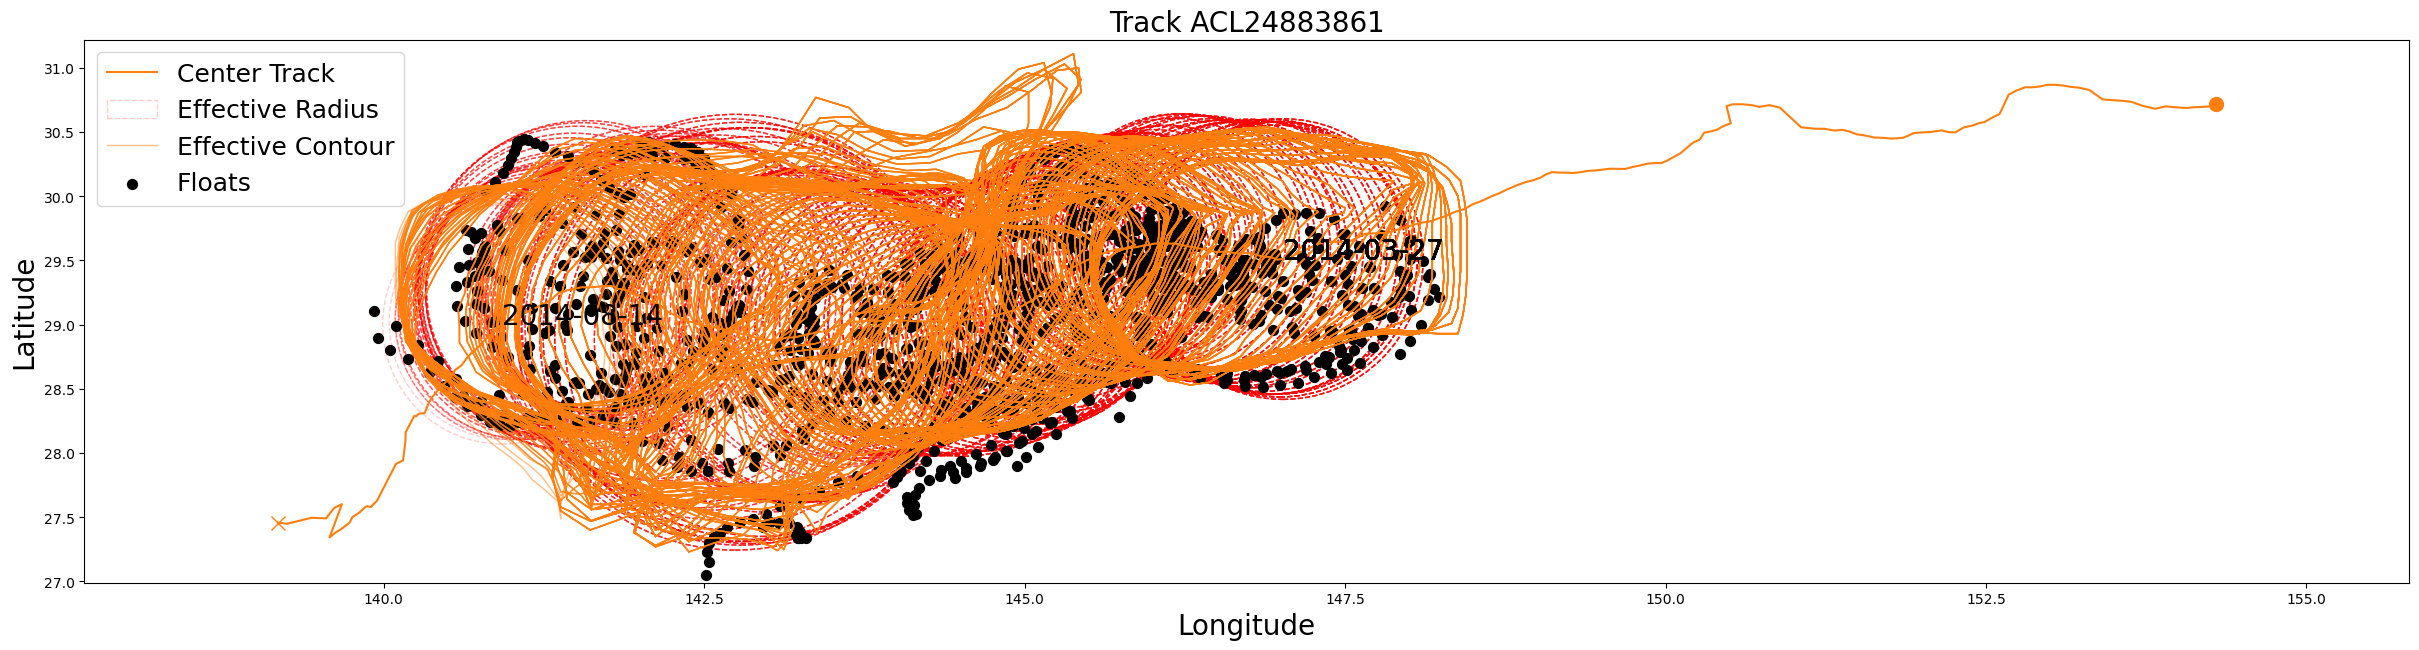

In [3]:
track.plot_track(acl, 24883861)

In [4]:
track.argo_data= pd.read_parquet("Argo2013.parquet")

/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:186: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


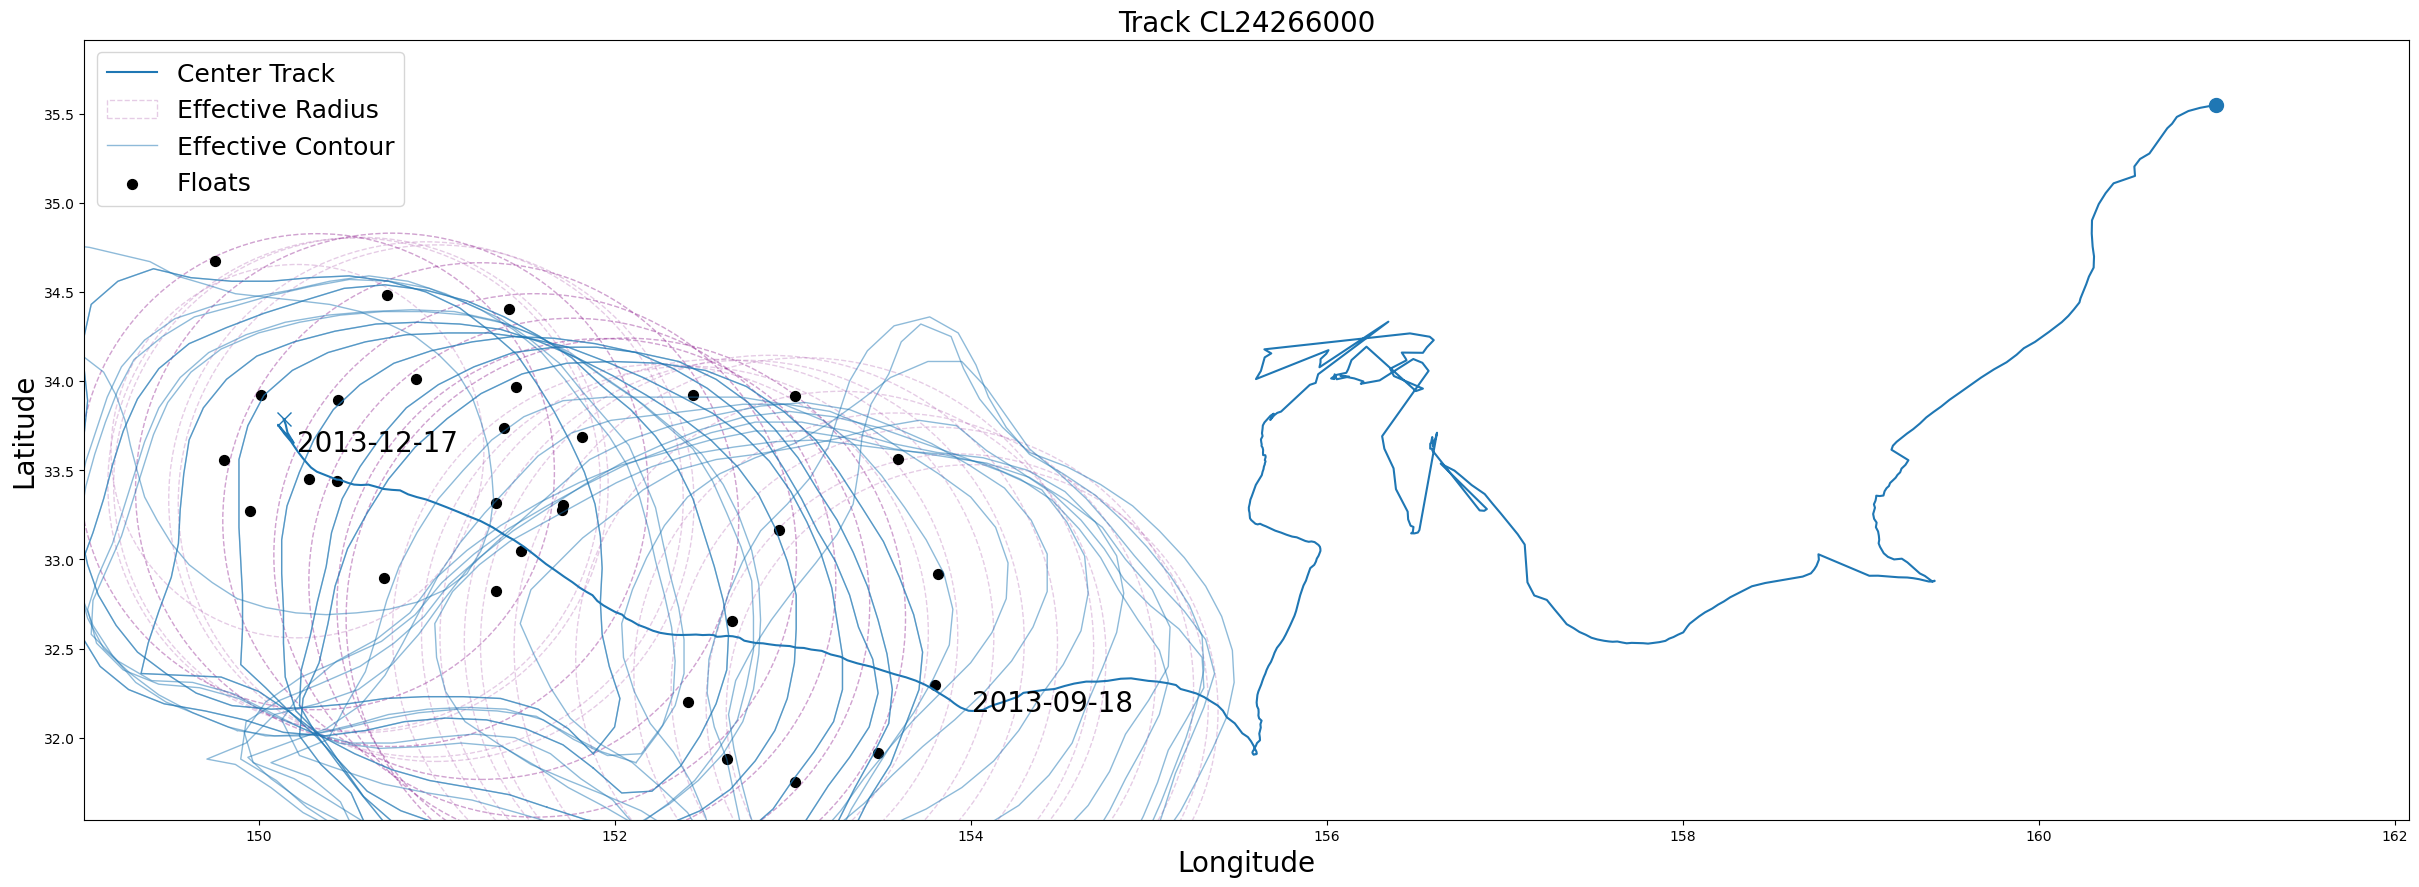

In [5]:
track.plot_track(cl, 24266000)

# Read GLORYS Data

In [3]:
acl_track_1=track.find_track(acl, 24883861)
test_eddy=acl_track_1[114]
test_date=track.convert_date(test_eddy[1])
print(test_date)

2014-03-27 00:00:00


In [4]:
Glorys_path = '../copernicus/GLORYS'
test_path = os.path.join(Glorys_path, test_date.strftime("%Y"), test_date.strftime("%m"), 'mercatorglorys12v1_gl12_mean_')
test_path += test_date.strftime("%Y%m%d")
matches = glob.glob(test_path + '_R*')
if matches:
    test_path = matches[0]
    print("Matching file:", test_path)
else:
    print("No matching file found.")

Matching file: ../copernicus/GLORYS/2014/03/mercatorglorys12v1_gl12_mean_20140327_R20140402.nc


In [5]:
test_Glorys = Dataset(test_path)
for var in test_Glorys.variables:
    print(var,test_Glorys.variables[var].standard_name)
    print(test_Glorys.variables[var].dimensions,test_Glorys.variables[var].shape)

longitude longitude
('longitude',) (4320,)
latitude latitude
('latitude',) (2041,)
depth depth
('depth',) (50,)
time time
('time',) (1,)
mlotst ocean_mixed_layer_thickness_defined_by_sigma_theta
('time', 'latitude', 'longitude') (1, 2041, 4320)
zos sea_surface_height_above_geoid
('time', 'latitude', 'longitude') (1, 2041, 4320)
bottomT sea_water_potential_temperature_at_sea_floor
('time', 'latitude', 'longitude') (1, 2041, 4320)
sithick sea_ice_thickness
('time', 'latitude', 'longitude') (1, 2041, 4320)
siconc sea_ice_area_fraction
('time', 'latitude', 'longitude') (1, 2041, 4320)
usi eastward_sea_ice_velocity
('time', 'latitude', 'longitude') (1, 2041, 4320)
vsi northward_sea_ice_velocity
('time', 'latitude', 'longitude') (1, 2041, 4320)
thetao sea_water_potential_temperature
('time', 'depth', 'latitude', 'longitude') (1, 50, 2041, 4320)
so sea_water_salinity
('time', 'depth', 'latitude', 'longitude') (1, 50, 2041, 4320)
uo eastward_sea_water_velocity
('time', 'depth', 'latitude', 'lo

In [6]:
lon = test_Glorys.variables['longitude'][:]
lat = test_Glorys.variables['latitude'][:]
depth = test_Glorys.variables['depth'][:]
thetao = test_Glorys.variables['thetao'][0,0,:,:]

In [7]:
from matplotlib.path import Path

# 构造封闭多边形(使用test_eddy中的轮廓坐标)
polygon = Path(np.column_stack((test_eddy[6], test_eddy[7])))

# 生成二维经纬度网格，注意: lon 和 lat 已定义为一维数组
LON, LAT = np.meshgrid(lon, lat)

# 判断网格内的点是否在多边形内
points = np.vstack((LON.ravel(), LAT.ravel())).T
inside = polygon.contains_points(points).reshape(LON.shape)

# 用掩码提取thetao中在多边形内部的区域，其外部设为nan
thetao_region = np.where(inside, thetao, np.nan)



In [8]:
test_float=track.filtered_float_data(acl, 24883861)

In [9]:
test_float_filtered = test_float[(test_float['Month'] == test_date.month) & (test_float['Day'] == test_date.day)]

In [10]:
test_float_filtered

,Year,Month,Day,Longitude,Latitude,Depth_m,DO_mol_kg,Temperature_degC,Profile_number,Platform_number
376990,2014.0,3.0,27.0,147.812888,29.927607,0.200000,233.887650,18.542000,35203.0,2901550.0
376991,2014.0,3.0,27.0,147.812888,29.927607,1.200000,233.697906,18.535999,35203.0,2901550.0
376992,2014.0,3.0,27.0,147.812888,29.927607,3.500000,233.912262,18.537001,35203.0,2901550.0
376993,2014.0,3.0,27.0,147.812888,29.927607,5.300000,233.342239,18.532000,35203.0,2901550.0
376994,2014.0,3.0,27.0,147.812888,29.927607,7.000000,233.470352,18.527000,35203.0,2901550.0
...,...,...,...,...,...,...,...,...,...,...
395882,2014.0,3.0,27.0,147.128965,29.269378,433.700012,194.175156,15.403000,36938.0,2901562.0
395883,2014.0,3.0,27.0,147.128965,29.269378,435.500000,194.437820,15.369000,36938.0,2901562.0
395884,2014.0,3.0,27.0,147.128965,29.269378,437.299988,194.704575,15.311000,36938.0,2901562.0
395885,2014.0,3.0,27.0,147.128965,29.269378,439.600006,194.645920,15.296000,36938.0,2901562.0


/tmp/ipykernel_2439310/1175299194.py:4: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='thetao')


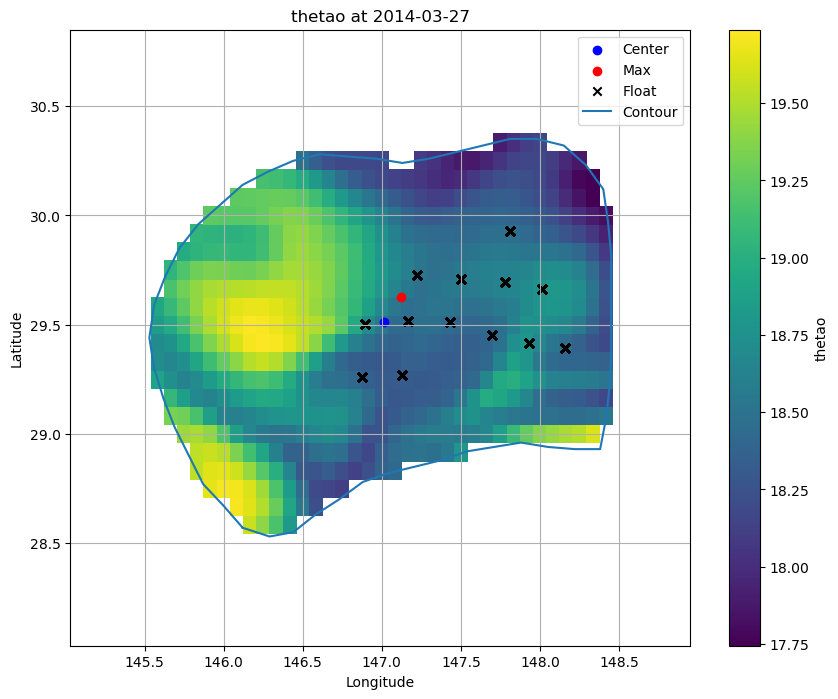

In [11]:
# 可视化提取结果
plt.figure(figsize=(10, 8))
plt.pcolor(lon, lat, thetao_region, shading='auto')
plt.colorbar(label='thetao')
plt.scatter(test_eddy[2], test_eddy[3], label='Center', color='blue')
plt.scatter(test_eddy[4], test_eddy[5], label='Max', color='red')
plt.scatter(test_float_filtered['Longitude'], test_float_filtered['Latitude'], label='Float', color='black', marker='x')
plt.plot(test_eddy[6], test_eddy[7], label='Contour')
plt.xlim([min(test_eddy[6])-0.5, max(test_eddy[6])+0.5])
plt.ylim([min(test_eddy[7])-0.5, max(test_eddy[7])+0.5])
plt.title(f'thetao at {test_date.strftime("%Y-%m-%d")}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid()
plt.show()

# Utilize Depth Data

In [2]:
with open('acs.pkl', 'rb') as f:
    acs = pickle.load(f)

with open('acl.pkl', 'rb') as f:
    acl = pickle.load(f)

with open('cs.pkl', 'rb') as f:
    cs = pickle.load(f)

with open('cl.pkl', 'rb') as f:
    cl = pickle.load(f)

In [3]:
argo_data = pd.read_parquet("Argo2014.parquet")
print(np.unique(argo_data["Datasets_number"])) #datasets_number==1 means Argo data

argo_data = pd.read_parquet("Argo2013.parquet")
print(np.unique(argo_data["Datasets_number"])) #datasets_number==1 means Argo data


[1.]
[1.]


## Track platform

In [4]:
track.plot_vertical(acl, 24883861, save_fig=True)

track.plot_vertical(acl, 24883861, save_fig=True, variable='Temp')

track.plot_relative_position(acl, 24883861, save_fig=True)

In [5]:
track.plot_vertical(acl, 25380376, save_fig=True)

track.plot_vertical(acl, 25380376, save_fig=True, variable='Temp')

track.plot_relative_position(acl, 25380376, save_fig=True)

In [6]:
# track.plot_vertical(cl, 26073128, save_fig=True)

# track.plot_relative_position(cl, 26073128, save_fig=True)

In [7]:
track.plot_vertical(cl, 26110937, save_fig=True)

track.plot_vertical(cl, 26110937, save_fig=True, variable='Temp')

track.plot_relative_position(cl, 26110937, save_fig=True)

In [8]:
track.plot_vertical(cl, 26327302, save_fig=True)

track.plot_vertical(cl, 26327302, save_fig=True, variable='Temp')

track.plot_relative_position(cl, 26327302, save_fig=True)

In [9]:
track.argo_data= pd.read_parquet("Argo2013.parquet")

In [10]:
track.plot_vertical(cl, 24266000, save_fig=True)

track.plot_vertical(cl, 24266000, save_fig=True, variable='Temp')

track.plot_relative_position(cl, 24266000, save_fig=True)

In [11]:
track.plot_vertical(acl, 24546743, save_fig=True)

track.plot_vertical(acl, 24546743, save_fig=True, variable='Temp')

track.plot_relative_position(acl, 24546743, save_fig=True)

In [12]:
# track.plot_vertical(cl, 24906981, save_fig=True)

# track.plot_relative_position(cl, 24906981, save_fig=True)

# track.plot_vertical(cl, 25704129, save_fig=True)

# track.plot_relative_position(cl, 25704129, save_fig=True)

## Track Date

In [13]:
track.plot_vertical_monthly(cl, 24266000,[9,10], save_fig=True)
track.plot_vertical_monthly(cl, 24266000,[9,10], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(cl, 24266000,[9,10], save_fig=True)

track.plot_vertical_monthly(cl, 24266000,[11,12], save_fig=True)
track.plot_vertical_monthly(cl, 24266000,[11,12], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(cl, 24266000,[11,12], save_fig=True)

Figure saved to: plot_vertical_DO_monthly_aggregated/CL24266000_DO_months_9_10_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/CL24266000_Temp_months_9_10_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/CL24266000_RP_months_9_10_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/CL24266000_DO_months_11_12_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/CL24266000_Temp_months_11_12_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/CL24266000_RP_months_11_12_aggregated.png


In [16]:
track.plot_vertical_monthly(acl, 24546743,[8], save_fig=True)
track.plot_vertical_monthly(acl, 24546743,[8], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(acl, 24546743,[8], save_fig=True)

track.plot_vertical_monthly(acl, 24546743,[9], save_fig=True)
track.plot_vertical_monthly(acl, 24546743,[9], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(acl, 24546743,[9], save_fig=True)

Figure saved to: plot_vertical_DO_monthly_aggregated/ACL24546743_DO_months_8_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/ACL24546743_Temp_months_8_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/ACL24546743_RP_months_8_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/ACL24546743_DO_months_9_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/ACL24546743_Temp_months_9_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/ACL24546743_RP_months_9_aggregated.png


In [17]:
track.argo_data= pd.read_parquet("Argo2014.parquet")

In [18]:
track.plot_vertical_monthly(acl, 24883861, [3,4], save_fig=True)
track.plot_vertical_monthly(acl, 24883861, [3,4], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(acl, 24883861, [3,4], save_fig=True)

track.plot_vertical_monthly(acl, 24883861, [5,6], save_fig=True)
track.plot_vertical_monthly(acl, 24883861, [5,6], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(acl, 24883861, [5,6], save_fig=True)

track.plot_vertical_monthly(acl, 24883861, [7,8], save_fig=True)
track.plot_vertical_monthly(acl, 24883861, [7,8], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(acl, 24883861, [7,8], save_fig=True)

Figure saved to: plot_vertical_DO_monthly_aggregated/ACL24883861_DO_months_3_4_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/ACL24883861_Temp_months_3_4_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/ACL24883861_RP_months_3_4_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/ACL24883861_DO_months_5_6_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/ACL24883861_Temp_months_5_6_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/ACL24883861_RP_months_5_6_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/ACL24883861_DO_months_7_8_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/ACL24883861_Temp_months_7_8_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/ACL24883861_RP_months_7_8_aggregated.png


In [19]:
track.plot_vertical_monthly(cl, 26110937,[4], save_fig=True)
track.plot_vertical_monthly(cl, 26110937,[4], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(cl, 26110937,[4], save_fig=True)

track.plot_vertical_monthly(cl, 26110937,[5], save_fig=True)
track.plot_vertical_monthly(cl, 26110937,[5], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(cl, 26110937,[5], save_fig=True)

track.plot_vertical_monthly(cl, 26110937,[6], save_fig=True)
track.plot_vertical_monthly(cl, 26110937,[6], save_fig=True, variable='Temp')
track.plot_relative_position_monthly(cl, 26110937,[6], save_fig=True)

Figure saved to: plot_vertical_DO_monthly_aggregated/CL26110937_DO_months_4_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/CL26110937_Temp_months_4_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/CL26110937_RP_months_4_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/CL26110937_DO_months_5_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/CL26110937_Temp_months_5_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/CL26110937_RP_months_5_aggregated.png
Figure saved to: plot_vertical_DO_monthly_aggregated/CL26110937_DO_months_6_aggregated.png
Figure saved to: plot_vertical_Temp_monthly_aggregated/CL26110937_Temp_months_6_aggregated.png
Figure saved to: plot_relative_position_monthly_aggregated/CL26110937_RP_months_6_aggregated.png
